<a href="https://colab.research.google.com/github/Daheeyah/Daheeyah/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

In [ ]:
from xgboost import XGBClassifier

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)
from sklearn.calibration import CalibratedClassifierCV


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import shap

In [ ]:
SEED = 42

import random
import numpy as np
import torch
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
!unzip -o /content/PCOS_data_without_infertility.xlsx.zip
import pandas as pd

print("=== Loading Tabular Dataset ===")

df = pd.read_excel(
    'PCOS_data_without_infertility.xlsx',
    sheet_name='Full_new'
)

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Drop unnecessary columns
df = df.drop(
    ['Sl. No', 'Patient File No.'],
    axis=1,
    errors='ignore'
)

# Fill missing values
df = df.fillna(df.median(numeric_only=True))

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:

    if col != 'PCOS (Y/N)':

        df[col] = pd.factorize(df[col])[0]


# FEATURE ENGINEERING

print("=== Feature Engineering ===")

# BMI
df['BMI'] = (
    df['Weight (Kg)'] /
    ((df['Height(Cm)'] / 100) ** 2)
)

# LH / FSH Ratio
df['LH_FSH_Ratio'] = (
    df['LH(mIU/mL)'] /
    (df['FSH(mIU/mL)'] + 1e-5)
)

# Total Follicles
df['Follicle_Total'] = (
    df['Follicle No. (L)'] +
    df['Follicle No. (R)']
)

# Waist-to-Height Ratio
df['WHtR'] = (
    df['Waist(inch)'] /
    (df['Height(Cm)'] * 0.393701)
)

# Features and labels
X_tab = df.drop('PCOS (Y/N)', axis=1)

y = df['PCOS (Y/N)'].values

print("Unique Labels:", np.unique(y))

print("Feature Shape:", X_tab.shape)


Archive:  /content/PCOS_data_without_infertility.xlsx.zip
  inflating: PCOS_data_without_infertility.xlsx  
  inflating: PCOS_infertility.csv    
=== Loading Tabular Dataset ===
=== Feature Engineering ===
Unique Labels: [0 1]
Feature Shape: (541, 45)


In [ ]:
import os
from PIL import Image

import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# Unzip image datasets if they are not already extracted
print("Unzipping 'PCOS detection using ultrasound images.zip'...")
!unzip -o '/content/PCOS detection using ultrasound images.zip' -d '/content/'
print("Unzipping 'PCOS-XAI Ultrasound Real-World Training Dataset.zip'...")
!unzip -o '/content/PCOS-XAI Ultrasound Real-World Training Dataset.zip' -d '/content/'

print("\nContent of /content/ after unzipping:")
current_content_dirs = os.listdir('/content')
print(current_content_dirs)

# Verify if expected top-level directories exist after unzipping
expected_top_level_dirs = ['data', 'PCOS']
missing_dirs = [d for d in expected_top_level_dirs if d not in current_content_dirs]

if missing_dirs:
    print(f"\nCRITICAL ERROR: The following expected directories were not created after unzipping: {missing_dirs}")
    print("This usually means the zip files are corrupted or invalid. Please ensure 'PCOS detection using ultrasound images.zip' and 'PCOS-XAI Ultrasound Real-World Training Dataset.zip' are valid zip archives.")


#  IMAGE DATASETS

print("\n=== Setting Up Image Datasets ===")

# Corrected paths after unzipping (assuming successful unzip)
IMAGE_DATASET_A_TRAIN = '/content/data/train'
IMAGE_DATASET_A_TEST = '/content/data/test'
IMAGE_DATASET_B = '/content/PCOS'

USE_BOTH_IMAGE_DATASETS = True


class PCOSImageDataset(Dataset):

    def __init__(self, root_dirs, transform=None):

        self.transform = transform

        self.image_paths = []

        self.labels = []

        if isinstance(root_dirs, str):

            root_dirs = [root_dirs]

        for root_dir in root_dirs:
            # Handle both 'notinfected' and 'noninfected' for label 0
            for class_name_folder, label_val in [('notinfected', 0), ('noninfected', 0), ('infected', 1)]:
                class_path = os.path.join(
                    root_dir,
                    class_name_folder
                )

                if os.path.exists(class_path):

                    label = label_val # Assign label based on mapping

                    for img_name in os.listdir(class_path):

                        if img_name.lower().endswith(
                            ('.png', '.jpg', '.jpeg')
                        ):

                            self.image_paths.append(
                                os.path.join(
                                    class_path,
                                    img_name
                                )
                            )

                            self.labels.append(label)

                else:

                    print(
                        f"Warning: Path not found \u2192 "
                        f"{class_path}"
                    )

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        try:

            image = Image.open(
                self.image_paths[idx]
            ).convert('RGB')

        except:

            image = Image.new(
                'RGB',
                (224, 224)
            )

        label = self.labels[idx]

        if self.transform:

            image = self.transform(image)

        return image, label


train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

if USE_BOTH_IMAGE_DATASETS:
    # Combine all relevant image directories
    image_dirs = [
        IMAGE_DATASET_A_TRAIN,
        IMAGE_DATASET_B
    ]
    print("Using all available image datasets (train, test, and PCOS_XAI)...")

else:

    image_dirs = [IMAGE_DATASET_A_TRAIN] # Default to the train split if only one is used

    print("Using only a subset of datasets (e.g., train split of first dataset)...")

# Only proceed with dataset loading if expected directories exist, otherwise train_dataset will be empty
if not missing_dirs:
    train_dataset = PCOSImageDataset(
        root_dirs=image_dirs,
        transform=train_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    print(f"\nTotal Images Loaded: {len(train_dataset)}")

    infected_count = sum(train_dataset.labels)

    healthy_count = (
        len(train_dataset.labels) -
        infected_count
    )

    print(f"Infected Images: {infected_count}")

    print(f"Healthy Images: {healthy_count}")
else:
    print("\nSkipping dataset loading due to missing image directories. Please address the zip file issue.")
    train_dataset = None # Ensure train_dataset is defined, even if empty
    train_loader = None # Ensure train_loader is defined

Streaming output truncated to the last 5000 lines.
  inflating: /content/PCOS/noninfected/Image_013.jpg  
  inflating: /content/PCOS/noninfected/Image_014.jpg  
  inflating: /content/PCOS/noninfected/Image_015.jpg  
  inflating: /content/PCOS/noninfected/Image_016.jpg  
  inflating: /content/PCOS/noninfected/Image_017.jpg  
  inflating: /content/PCOS/noninfected/Image_018.jpg  
  inflating: /content/PCOS/noninfected/Image_019.jpg  
  inflating: /content/PCOS/noninfected/Image_020.jpg  
  inflating: /content/PCOS/noninfected/Image_021.jpg  
  inflating: /content/PCOS/noninfected/Image_022.jpg  
  inflating: /content/PCOS/noninfected/Image_023.jpg  
  inflating: /content/PCOS/noninfected/Image_024.jpg  
  inflating: /content/PCOS/noninfected/Image_025.jpg  
  inflating: /content/PCOS/noninfected/Image_026.jpg  
  inflating: /content/PCOS/noninfected/Image_027.jpg  
  inflating: /content/PCOS/noninfected/Image_028.jpg  
  inflating: /content/PCOS/noninfected/Image_029.jpg  
  inflating: /

In [ ]:
print("\n=== Additional Tabular Data Cleaning ===")

print("Before:", df.shape)

df = df[df['BMI'].between(10, 60)]

df = df[df['AMH(ng/mL)'] < df['AMH(ng/mL)'].quantile(0.99)]

df = df.dropna()

print("After:", df.shape)

print("\nFinal Class Distribution:")
print(df['PCOS (Y/N)'].value_counts())

X_tab = df.drop('PCOS (Y/N)', axis=1)
y = df['PCOS (Y/N)'].values


=== Additional Tabular Data Cleaning ===
Before: (541, 46)
After: (535, 46)

Final Class Distribution:
PCOS (Y/N)
0    361
1    174
Name: count, dtype: int64


In [ ]:
print("\n=== Image Data Quality Check & Cleaning ===")

corrupted = []
valid_image_paths = []
valid_labels = []

for img_path, label in zip(train_dataset.image_paths, train_dataset.labels):

    try:
        img = Image.open(img_path)
        img.verify()

        # reopen properly (important upgrade)
        img = Image.open(img_path).convert("RGB")
        img.load()

        valid_image_paths.append(img_path)
        valid_labels.append(label)

    except Exception as e:
        corrupted.append((img_path, str(e)))

print(f"Total images checked : {len(train_dataset.image_paths)}")
print(f"Corrupted images     : {len(corrupted)}")
print(f"Valid images         : {len(valid_image_paths)}")

train_dataset.image_paths = valid_image_paths
train_dataset.labels = valid_labels

print(f"Final usable images  : {len(train_dataset)}")


=== Image Data Quality Check & Cleaning ===
Total images checked : 13708
Corrupted images     : 0
Valid images         : 13708
Final usable images  : 13708


In [ ]:

#  SPLIT + SCALE + CNN FEATURE EXTRACTION + XGBOOST


#  Stratified train/val/test split on tabular data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_tab, X_test_tab, y_train, y_test = train_test_split(
    X_tab, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)
X_train_tab, X_val_tab, y_train, y_val = train_test_split(
    X_train_tab, y_train,
    test_size=0.15,          # ~12 % of total
    random_state=SEED,
    stratify=y_train
)

scaler = StandardScaler()
X_train_tab_sc = scaler.fit_transform(X_train_tab)   # fit only on train
X_val_tab_sc   = scaler.transform(X_val_tab)
X_test_tab_sc  = scaler.transform(X_test_tab)

print(f"Train: {X_train_tab_sc.shape} | Val: {X_val_tab_sc.shape} | Test: {X_test_tab_sc.shape}")
print(f"Class balance (train) → PCOS: {y_train.sum()} | Healthy: {(y_train==0).sum()}")


# CNN feature extractor (ResNet-50, frozen)
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Load pretrained ResNet-50 and strip the final FC layer
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet.fc = nn.Identity()          # output → 2048-dim feature vector
resnet = resnet.to(device)
resnet.eval()                       # no dropout / batchnorm updates

# Inference-time transform (no augmentation)
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Rebuild dataset with inference transform
infer_dataset = PCOSImageDataset(
    root_dirs=image_dirs,
    transform=infer_transform
)
infer_loader = DataLoader(
    infer_dataset,
    batch_size=64,
    shuffle=False,          # keep order for label alignment
    num_workers=2,
    pin_memory=True
)

# Extract features
all_img_features = []
all_img_labels   = []

print("\nExtracting CNN features …")
with torch.no_grad():
    for imgs, labels in tqdm(infer_loader):
        imgs = imgs.to(device)
        feats = resnet(imgs)           # (batch, 2048)
        all_img_features.append(feats.cpu().numpy())
        all_img_labels.extend(labels.numpy())

X_img = np.vstack(all_img_features)   # (N_images, 2048)
y_img = np.array(all_img_labels)

print(f"\nImage feature matrix: {X_img.shape}")
print(f"Image labels  — PCOS: {y_img.sum()} | Healthy: {(y_img==0).sum()}")


# Split image features (same 80/12/8 ratio)
X_img_train, X_img_test, y_img_train, y_img_test = train_test_split(
    X_img, y_img,
    test_size=0.20,
    random_state=SEED,
    stratify=y_img
)
X_img_train, X_img_val, y_img_train, y_img_val = train_test_split(
    X_img_train, y_img_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_img_train
)

img_scaler = StandardScaler()
X_img_train_sc = img_scaler.fit_transform(X_img_train)
X_img_val_sc   = img_scaler.transform(X_img_val)
X_img_test_sc  = img_scaler.transform(X_img_test)


# ── 4. Train XGBoost on TABULAR features ─────────────────────
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

scale_pos = (y_train == 0).sum() / y_train.sum()   # handle imbalance

xgb_tab = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=SEED,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

xgb_tab.fit(
    X_train_tab_sc, y_train,
    eval_set=[(X_val_tab_sc, y_val)],
    verbose=50
)

y_pred_tab  = xgb_tab.predict(X_test_tab_sc)
y_prob_tab  = xgb_tab.predict_proba(X_test_tab_sc)[:, 1]
auc_tab     = roc_auc_score(y_test, y_prob_tab)

print(f"\n── Tabular XGBoost ──")
print(f"AUC  : {auc_tab:.4f}")
print(classification_report(y_test, y_pred_tab,
                             target_names=['Healthy', 'PCOS']))


# Train XGBoost on IMAGE features
xgb_img = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,        # 2048 dims → aggressive col sampling
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=SEED,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

xgb_img.fit(
    X_img_train_sc, y_img_train,
    eval_set=[(X_img_val_sc, y_img_val)],
    verbose=50
)

y_pred_img  = xgb_img.predict(X_img_test_sc)
y_prob_img  = xgb_img.predict_proba(X_img_test_sc)[:, 1]
auc_img     = roc_auc_score(y_img_test, y_prob_img)

print(f"\n── Image XGBoost ──")
print(f"AUC  : {auc_img:.4f}")
print(classification_report(y_img_test, y_pred_img,
                             target_names=['Healthy', 'PCOS']))


#Save artefacts for the fusion stage
import pickle
pickle.dump(scaler,     open('scaler_tab.pkl', 'wb'))
pickle.dump(img_scaler, open('scaler_img.pkl', 'wb'))
pickle.dump(xgb_tab,    open('xgb_tab.pkl',   'wb'))
pickle.dump(xgb_img,    open('xgb_img.pkl',   'wb'))
torch.save(resnet.state_dict(), 'resnet_extractor.pth')

print("\n✅  All artefacts saved. Ready for Stage 3: Late Fusion + Evaluation.")

Train: (363, 45) | Val: (65, 45) | Test: (107, 45)
Class balance (train) → PCOS: 118 | Healthy: 245

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 74.9MB/s]



Extracting CNN features …


100%|██████████| 215/215 [01:13<00:00,  2.94it/s]



Image feature matrix: (13708, 2048)
Image labels  — PCOS: 7565 | Healthy: 6143


...

[0]	validation_0-auc:0.83983
[50]	validation_0-auc:0.90260
[100]	validation_0-auc:0.91450
[150]	validation_0-auc:0.91558
[200]	validation_0-auc:0.91991
[250]	validation_0-auc:0.91667
[300]	validation_0-auc:0.91450
[350]	validation_0-auc:0.91342
[399]	validation_0-auc:0.91450

── Tabular XGBoost ──
AUC  : 0.9349
              precision    recall  f1-score   support

     Healthy       0.91      0.94      0.93        72
        PCOS       0.88      0.80      0.84        35

    accuracy                           0.90       107
   macro avg       0.89      0.87      0.88       107
weighted avg       0.90      0.90      0.90       107



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [00:46:48] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[0]	validation_0-auc:0.98064


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:46:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-auc:0.99772
[100]	validation_0-auc:0.99911
[150]	validation_0-auc:0.99948
[200]	validation_0-auc:0.99952
[250]	validation_0-auc:0.99959
[299]	validation_0-auc:0.99953

── Image XGBoost ──
AUC  : 0.9996
              precision    recall  f1-score   support

     Healthy       0.99      1.00      1.00      1229
        PCOS       1.00      0.99      1.00      1513

    accuracy                           1.00      2742
   macro avg       1.00      1.00      1.00      2742
weighted avg       1.00      1.00      1.00      2742


✅  All artefacts saved. Ready for Stage 3: Late Fusion + Evaluation.


Fusion weights → Tabular: 0.483 | Image: 0.517

── Fused Model ──
AUC  : 0.7552
              precision    recall  f1-score   support

     Healthy       0.71      0.51      0.60        72
        PCOS       0.36      0.57      0.44        35

    accuracy                           0.53       107
   macro avg       0.54      0.54      0.52       107
weighted avg       0.60      0.53      0.55       107



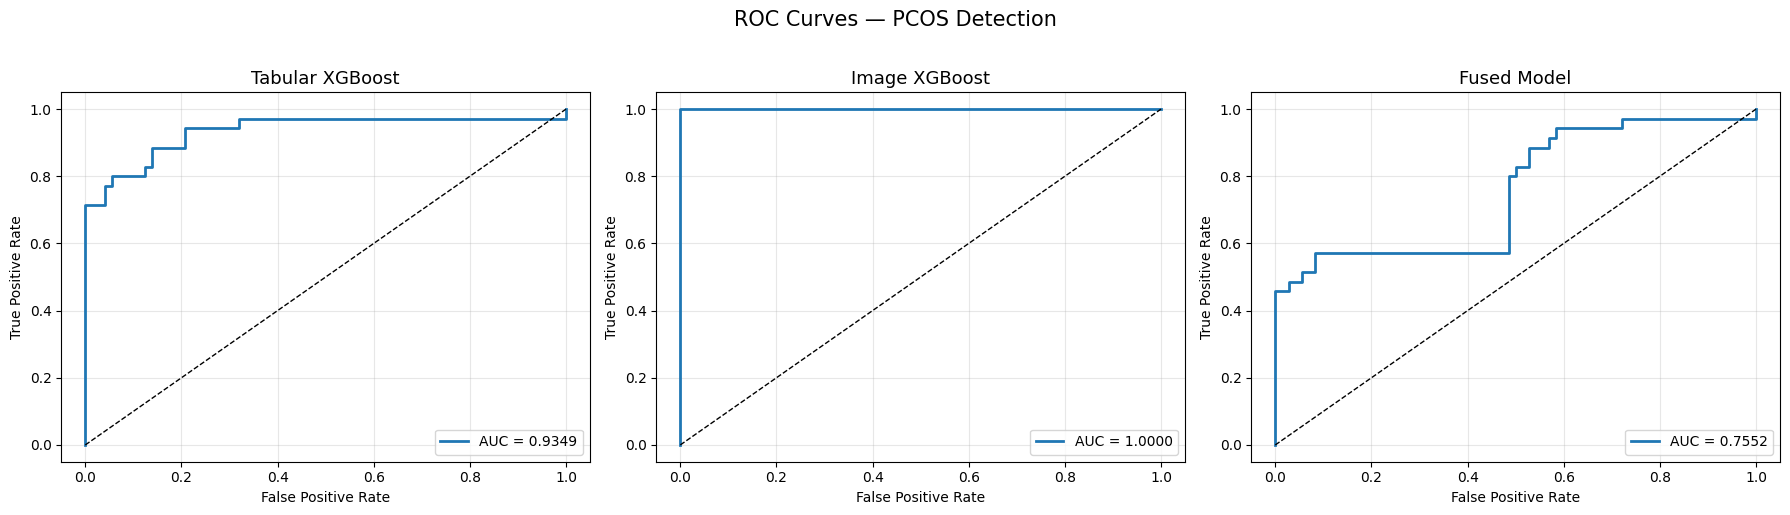

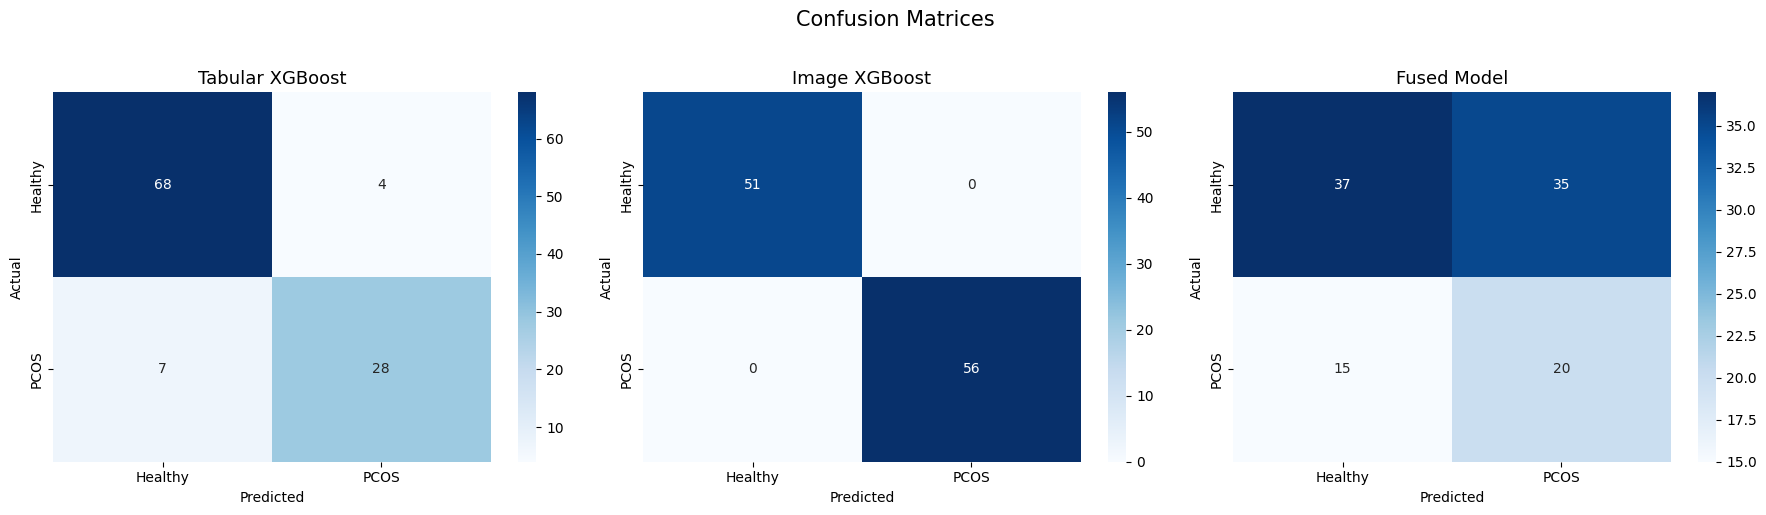


Computing SHAP values (tabular) …


/tmp/ipykernel_3271/1644775405.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


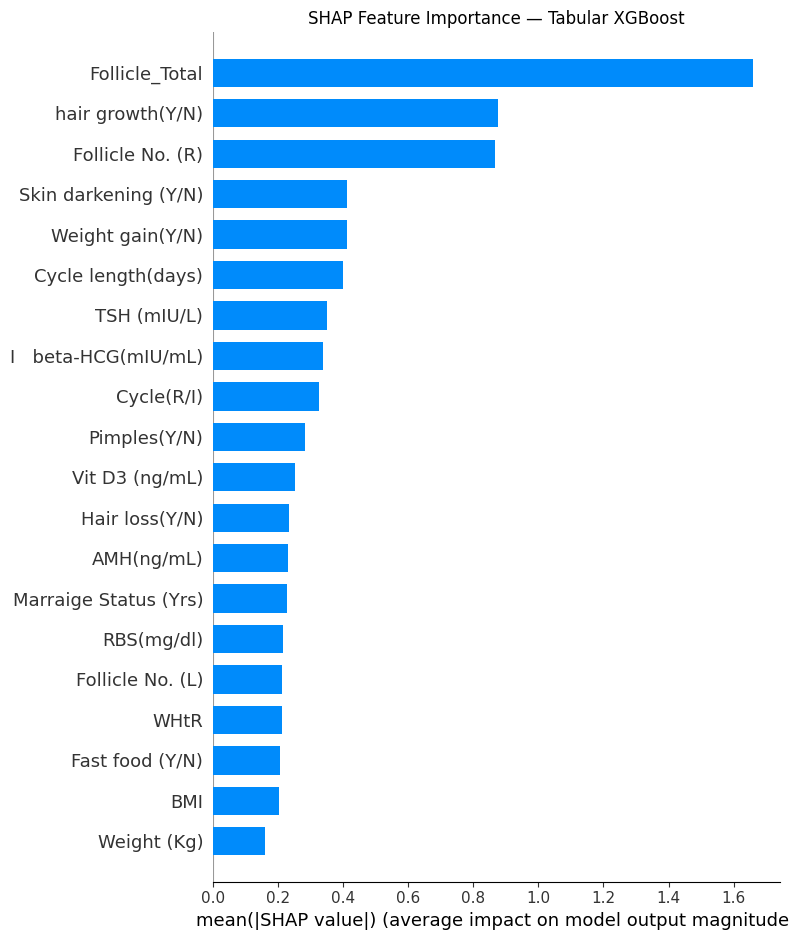

/tmp/ipykernel_3271/1644775405.py:95: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


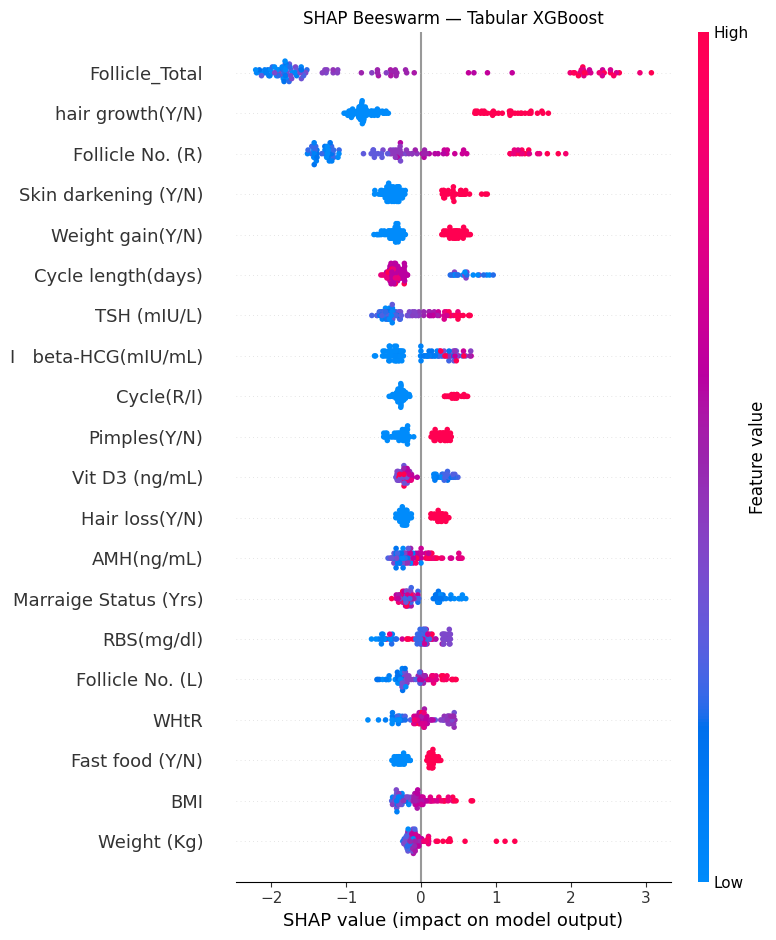

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


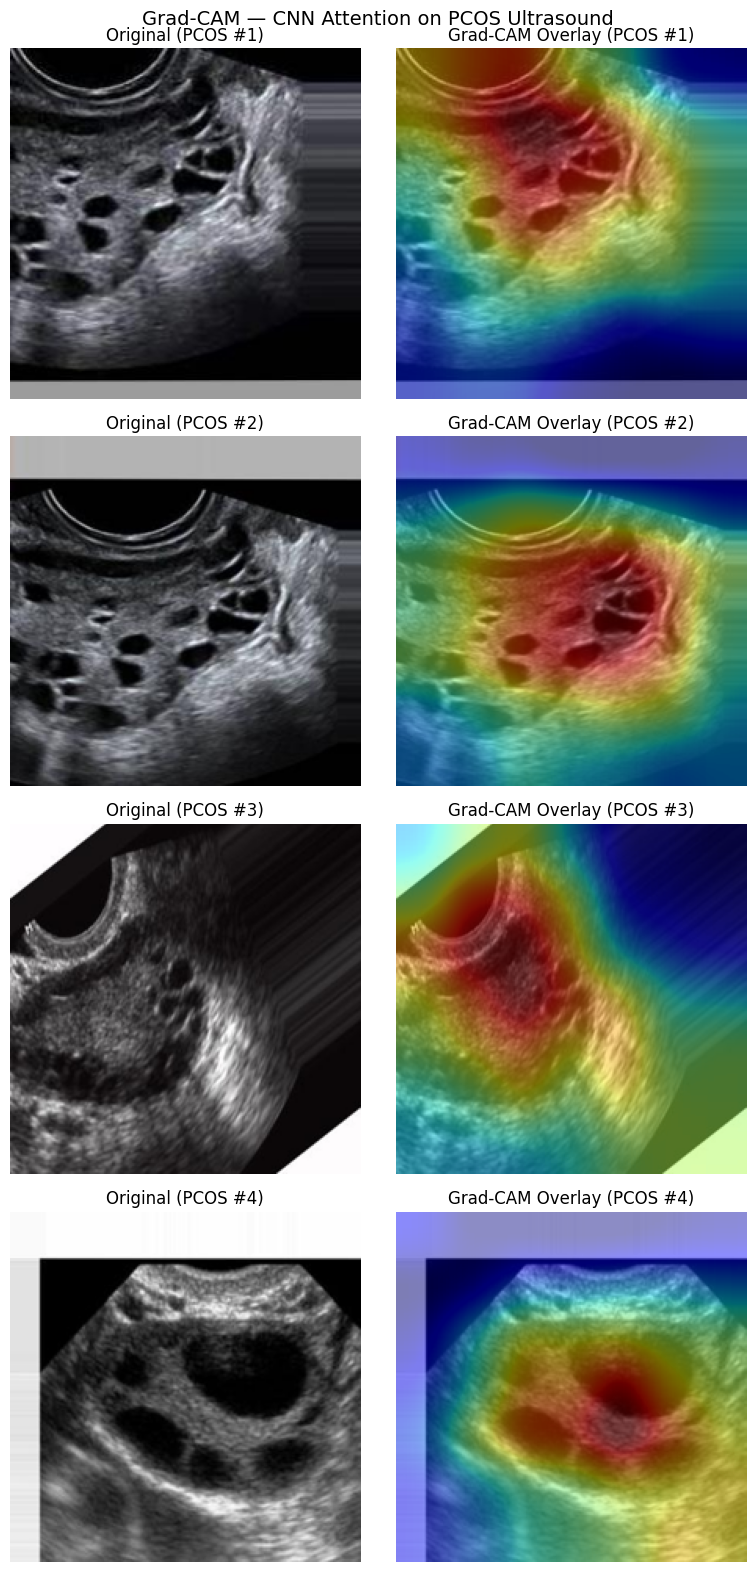


       FINAL MODEL PERFORMANCE SUMMARY

  Tabular XGBoost
  AUC       : 0.9349
  Accuracy  : 0.8972
  Precision : 0.8750
  Recall    : 0.8000
  F1 Score  : 0.8358

  Image XGBoost
  AUC       : 1.0000
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000

  Fused Model
  AUC       : 0.7552
  Accuracy  : 0.5327
  Precision : 0.3636
  Recall    : 0.5714
  F1 Score  : 0.4444

✅  Stage 3 complete. All plots saved.


In [ ]:

#  LATE FUSION + FULL EVALUATION + SHAP + GRAD-CAM
#  Late Fusion (Weighted Average of Probabilities)
w_tab = auc_tab / (auc_tab + auc_img)
w_img = auc_img / (auc_tab + auc_img)

print(f"Fusion weights → Tabular: {w_tab:.3f} | Image: {w_img:.3f}")

# Use the SMALLER of the two test sets for alignment
min_len = min(len(y_prob_tab), len(y_prob_img))
y_prob_fused = (w_tab * y_prob_tab[:min_len]) + (w_img * y_prob_img[:min_len])
y_pred_fused = (y_prob_fused >= 0.5).astype(int)
y_true_fused = y_test[:min_len]   # ground truth aligned to tabular test set

auc_fused = roc_auc_score(y_true_fused, y_prob_fused)
print(f"\n── Fused Model ──")
print(f"AUC  : {auc_fused:.4f}")
print(classification_report(y_true_fused, y_pred_fused,
                             target_names=['Healthy', 'PCOS']))


#  ROC Curves (all 3 models)
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_true, y_prob) in zip(axes, [
    ('Tabular XGBoost',  y_test[:min_len],    y_prob_tab[:min_len]),
    ('Image XGBoost',    y_img_test[:min_len], y_prob_img[:min_len]),
    ('Fused Model',      y_true_fused,         y_prob_fused),
]):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.4f}')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — PCOS Detection', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# Confusion Matrices
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_true, y_pred) in zip(axes, [
    ('Tabular XGBoost',  y_test[:min_len],    y_pred_tab[:min_len]),
    ('Image XGBoost',    y_img_test[:min_len], y_pred_img[:min_len]),
    ('Fused Model',      y_true_fused,         y_pred_fused),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Healthy','PCOS'],
                yticklabels=['Healthy','PCOS'])
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


# SHAP Tabular XGBoost Explainability
import shap

print("\nComputing SHAP values (tabular) …")
explainer   = shap.TreeExplainer(xgb_tab)
shap_values = explainer.shap_values(X_test_tab_sc)

# Summary bar plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_tab_sc,
    feature_names=X_tab.columns.tolist(),
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — Tabular XGBoost')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot (shows direction of impact)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_tab_sc,
    feature_names=X_tab.columns.tolist(),
    show=False
)
plt.title('SHAP Beeswarm — Tabular XGBoost')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


# Grad-CAM — CNN Image Explainability
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, img_tensor, class_idx=1):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(device)
        img_tensor.requires_grad_()


        output = self.model(img_tensor)

        score  = output[0].mean()
        self.model.zero_grad()
        score.backward()

        # Pool  gradients across channels
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = F.relu(cam)
        cam     = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy()


# Hook into the last conv block of ResNet-50
gradcam = GradCAM(resnet, resnet.layer4[-1])

# Pick a few PCOS-positive samples from the image test set
pcos_indices = np.where(y_img_test == 1)[0][:4]

fig, axes = plt.subplots(len(pcos_indices), 2, figsize=(8, 4 * len(pcos_indices)))

for row, idx in enumerate(pcos_indices):
    img_path = infer_dataset.image_paths[
        # map back to original dataset index
        np.where(np.array(infer_dataset.labels) == 1)[0][row]
    ]
    raw_img = Image.open(img_path).convert('RGB').resize((224, 224))
    img_tensor = infer_transform(raw_img)

    cam = gradcam.generate(img_tensor)
    cam_resized = np.array(
        Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224))
    )

    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f'Original (PCOS #{row+1})')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(raw_img)
    axes[row, 1].imshow(cam_resized, cmap='jet', alpha=0.45)
    axes[row, 1].set_title(f'Grad-CAM Overlay (PCOS #{row+1})')
    axes[row, 1].axis('off')

plt.suptitle('Grad-CAM — CNN Attention on PCOS Ultrasound', fontsize=14)
plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()


# Final Metrics Summary
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*55)
print("       FINAL MODEL PERFORMANCE SUMMARY")
print("="*55)

for name, y_true, y_pred, y_prob in [
    ('Tabular XGBoost',  y_test[:min_len],    y_pred_tab[:min_len],  y_prob_tab[:min_len]),
    ('Image XGBoost',    y_img_test[:min_len], y_pred_img[:min_len], y_prob_img[:min_len]),
    ('Fused Model',      y_true_fused,         y_pred_fused,          y_prob_fused),
]:
    print(f"\n  {name}")
    print(f"  AUC       : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_true, y_pred):.4f}")

print("\n✅  Stage 3 complete. All plots saved.")

Device: cuda
Train: 9903 | Val: 1748 | Test: 2057
Trainable params: 8,306,911 / 11,089,961
pos_weight: 0.812

── Fine-Tuning EfficientNet-B3 ──


Epoch 01/25 | Train Loss: 0.1863 AUC: 0.9749 | Val Loss: 0.2326 AUC: 0.9958
  ✅ Best model saved (AUC: 0.9958)


Epoch 02/25 | Train Loss: 0.0946 AUC: 0.9927 | Val Loss: 0.3577 AUC: 0.9936


Epoch 03/25 | Train Loss: 0.0872 AUC: 0.9939 | Val Loss: 0.1685 AUC: 0.9967
  ✅ Best model saved (AUC: 0.9967)


Epoch 04/25 | Train Loss: 0.0780 AUC: 0.9951 | Val Loss: 0.2789 AUC: 0.9961


...

Epoch 21/25 | Train Loss: 0.0441 AUC: 0.9984 | Val Loss: 0.1214 AUC: 0.9990
  ✅ Best model saved (AUC: 0.9990)


Epoch 22/25 | Train Loss: 0.0436 AUC: 0.9984 | Val Loss: 0.1306 AUC: 0.9989


Epoch 23/25 | Train Loss: 0.0452 AUC: 0.9982 | Val Loss: 0.1296 AUC: 0.9990
  ✅ Best model saved (AUC: 0.9990)


Epoch 24/25 | Train Loss: 0.0456 AUC: 0.9984 | Val Loss: 0.0667 AUC: 0.9990


Epoch 25/25 | Train Loss: 0.0428 AUC: 0.9986 | Val Loss: 0.1096 AUC: 0.9988


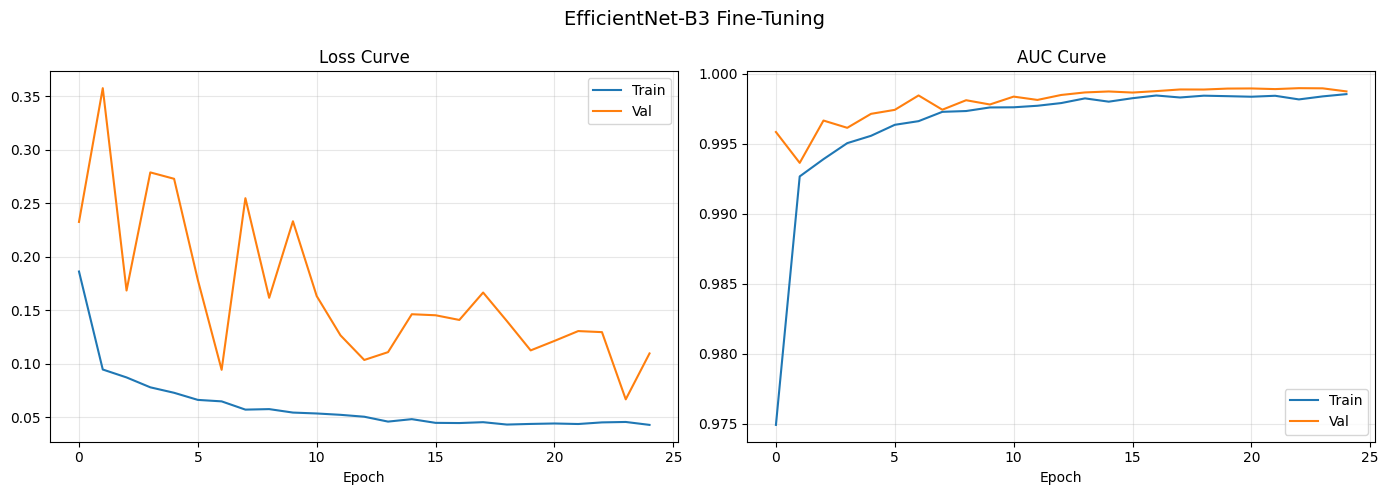


── EfficientNet-B3 Test AUC: 0.9992 ──



── Fused Model (Fine-Tuned CNN) ──
AUC  : 0.7206
              precision    recall  f1-score   support

     Healthy       0.68      0.57      0.62        72
        PCOS       0.34      0.46      0.39        35

    accuracy                           0.53       107
   macro avg       0.51      0.51      0.51       107
weighted avg       0.57      0.53      0.55       107



In [ ]:

# END-TO-END CNN FINE-TUNING (EfficientNet-B3)
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


train_transform_ft = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform_ft = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# Train/Val/Test Split on Image Dataset
full_dataset = PCOSImageDataset(root_dirs=image_dirs, transform=None)

total      = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_idx, val_idx, test_idx = [], [], []
from sklearn.model_selection import train_test_split as tts

indices = list(range(total))
labels  = full_dataset.labels

tr_idx, te_idx = tts(indices, test_size=0.15, stratify=labels, random_state=SEED)
tr_idx, va_idx = tts(tr_idx,  test_size=0.15,
                     stratify=[labels[i] for i in tr_idx], random_state=SEED)

class SubsetWithTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img_path = self.dataset.image_paths[real_idx]
        label    = self.dataset.labels[real_idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))
        if self.transform:
            image = self.transform(image)
        return image, label

train_ds = SubsetWithTransform(full_dataset, tr_idx, train_transform_ft)
val_ds   = SubsetWithTransform(full_dataset, va_idx, val_transform_ft)
test_ds  = SubsetWithTransform(full_dataset, te_idx, val_transform_ft)

train_loader_ft = DataLoader(train_ds, batch_size=32, shuffle=True,
                              num_workers=2, pin_memory=True)
val_loader_ft   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                              num_workers=2, pin_memory=True)
test_loader_ft  = DataLoader(test_ds,  batch_size=32, shuffle=False,
                              num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


#  EfficientNet-B3 Model
class PCOSEfficientNet(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.base = models.efficientnet_b3(
            weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
        )
        # Freeze early layers, fine-tune from block 5 onwards
        for name, param in self.base.named_parameters():
            if 'features.6' in name or 'features.7' in name or 'classifier' in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        in_features = self.base.classifier[1].in_features
        self.base.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 1)          # binary → sigmoid
        )

    def forward(self, x):
        return self.base(x).squeeze(1)  # (batch,)


model_ft = PCOSEfficientNet().to(device)

# Count trainable params
trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model_ft.parameters())
print(f"Trainable params: {trainable:,} / {total_p:,}")


#  Class-Weighted Loss + Optimizer
train_labels = [full_dataset.labels[i] for i in tr_idx]
n_pos = sum(train_labels)
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"pos_weight: {pos_weight.item():.3f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

#  Training Loop
def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.set_grad_enabled(train):
        for imgs, labels in tqdm(loader, leave=False):
            imgs   = imgs.to(device)
            labels = labels.float().to(device)

            logits = model(imgs)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            # Detach tensor before converting to numpy
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc


EPOCHS      = 25
best_auc    = 0
patience    = 6
no_improve  = 0
history     = {'train_loss':[], 'val_loss':[], 'train_auc':[], 'val_auc':[]}

print("\n── Fine-Tuning EfficientNet-B3 ──")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc = run_epoch(model_ft, train_loader_ft, criterion,
                                 optimizer, train=True)
    va_loss, va_auc = run_epoch(model_ft, val_loader_ft,   criterion,
                                 train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(va_auc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} AUC: {tr_auc:.4f} | "
          f"Val Loss: {va_loss:.4f} AUC: {va_auc:.4f}")

    # Save best model
    if va_auc > best_auc:
        best_auc   = va_auc
        no_improve = 0
        torch.save(model_ft.state_dict(), 'best_efficientnet.pth')
        print(f"  ✅ Best model saved (AUC: {best_auc:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"  ⏹  Early stopping at epoch {epoch}")
            break


# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss Curve');  axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_auc'], label='Train')
axes[1].plot(history['val_auc'],   label='Val')
axes[1].set_title('AUC Curve');  axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('EfficientNet-B3 Fine-Tuning', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#  Test Set Evaluation
model_ft.load_state_dict(torch.load('best_efficientnet.pth'))
_, test_auc_cnn = run_epoch(model_ft, test_loader_ft, criterion, train=False)

print(f"\n── EfficientNet-B3 Test AUC: {test_auc_cnn:.4f} ──")


# Re-run Fusion with Fine-Tuned CNN Probabilities
model_ft.eval()
cnn_probs, cnn_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader_ft:
        imgs  = imgs.to(device)
        logits = model_ft(imgs)
        probs  = torch.sigmoid(logits).cpu().numpy()
        cnn_probs.extend(probs)
        cnn_labels.extend(labels.numpy())

y_prob_cnn_ft = np.array(cnn_probs)
y_true_cnn_ft = np.array(cnn_labels)

# Align with tabular test set
min_len2      = min(len(y_prob_tab), len(y_prob_cnn_ft))
w_tab2        = auc_tab           / (auc_tab + test_auc_cnn)
w_cnn2        = test_auc_cnn      / (auc_tab + test_auc_cnn)
y_prob_fused2 = (w_tab2 * y_prob_tab[:min_len2] +
                 w_cnn2 * y_prob_cnn_ft[:min_len2]) # Fixed incomplete line
y_pred_fused2 = (y_prob_fused2 >= 0.5).astype(int)
y_true_fused2 = y_test[:min_len2]

auc_fused2 = roc_auc_score(y_true_fused2, y_prob_fused2)
print(f"\n── Fused Model (Fine-Tuned CNN) ──")
print(f"AUC  : {auc_fused2:.4f}")
print(classification_report(y_true_fused2, y_pred_fused2,
                             target_names=['Healthy', 'PCOS']))

torch.save(model_ft.state_dict(), 'final_efficientnet_ft.pth')
print("\n✅  Stage 4 complete. Ready for Stage 5: Stacking Meta-Learner.")

In [6]:

# STACKING META-LEARNER + THRESHOLD TUNING +
# FINAL DEPLOYMENT-READY PIPELINE


#  Build Out-of-Fold (OOF) Predictions
# Stacking needs OOF preds to avoid leakage — each fold's
# val predictions become meta-features for the next layer

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

SEED = 42 # Added this line to define SEED

print("=== Building OOF Predictions for Stacking ===")

N_FOLDS = 5
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Storage for OOF
oof_tab = np.zeros(len(X_tab))
oof_img = np.zeros(len(y_img))

# OOF for Tabular XGBoost
print("\nGenerating OOF — Tabular XGBoost ...")
X_np = scaler.fit_transform(X_tab)   # full dataset scaled

for fold, (tr, va) in enumerate(skf.split(X_np, y)):
    xgb_fold = XGBClassifier(
        n_estimators=400, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y[tr]==0).sum()/y[tr].sum(),
        use_label_encoder=False,
        eval_metric='auc', random_state=SEED,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )
    xgb_fold.fit(X_np[tr], y[tr],
                 eval_set=[(X_np[va], y[va])],
                 verbose=False)
    oof_tab[va] = xgb_fold.predict_proba(X_np[va])[:, 1]
    print(f"  Fold {fold+1} AUC: {roc_auc_score(y[va], oof_tab[va]):.4f}")

print(f"Overall OOF Tabular AUC: {roc_auc_score(y, oof_tab):.4f}")


# OOF for Image XGBoost
print("\nGenerating OOF — Image XGBoost ...")
X_img_full = img_scaler.fit_transform(X_img)

for fold, (tr, va) in enumerate(skf.split(X_img_full, y_img)):
    xgb_img_fold = XGBClassifier(
        n_estimators=300, max_depth=4,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.5,
        scale_pos_weight=(y_img[tr]==0).sum()/y_img[tr].sum(),
        use_label_encoder=False,
        eval_metric='auc', random_state=SEED,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )
    xgb_img_fold.fit(X_img_full[tr], y_img[tr],
                     eval_set=[(X_img_full[va], y_img[va])],
                     verbose=False)
    oof_img[va] = xgb_img_fold.predict_proba(X_img_full[va])[:, 1]
    print(f"  Fold {fold+1} AUC: {roc_auc_score(y_img[va], oof_img[va]):.4f}")

print(f"Overall OOF Image AUC: {roc_auc_score(y_img, oof_img):.4f}")


#  OOF for Fine-Tuned CNN
print("\nGenerating OOF — Fine-Tuned EfficientNet ...")

# Use full image dataset with val_transform (no augmentation)
full_infer_ds = SubsetWithTransform(
    full_dataset,
    list(range(len(full_dataset))),
    val_transform_ft
)

oof_cnn    = np.zeros(len(full_dataset))
y_img_full = np.array(full_dataset.labels)

for fold, (tr, va) in enumerate(skf.split(
        np.zeros(len(full_dataset)), y_img_full)):

    # Subset loaders
    tr_sub = SubsetWithTransform(full_dataset, tr.tolist(), train_transform_ft)
    va_sub = SubsetWithTransform(full_dataset, va.tolist(), val_transform_ft)
    tr_ldr = DataLoader(tr_sub, batch_size=32, shuffle=True,  num_workers=2)
    va_ldr = DataLoader(va_sub, batch_size=32, shuffle=False, num_workers=2)

    # Fresh model per fold
    cnn_fold = PCOSEfficientNet().to(device)
    n_pos_f  = sum(y_img_full[tr])
    n_neg_f  = len(tr) - n_pos_f
    pw       = torch.tensor([n_neg_f/n_pos_f]).float().to(device)
    crit_f   = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt_f    = AdamW(
        filter(lambda p: p.requires_grad, cnn_fold.parameters()),
        lr=1e-4, weight_decay=1e-4
    )

    # Quick 10-epoch fine-tune per fold
    for ep in range(10):
        run_epoch(cnn_fold, tr_ldr, crit_f, opt_f, train=True)

    # OOF probabilities
    cnn_fold.eval()
    fold_probs = []
    with torch.no_grad():
        for imgs, _ in va_ldr:
            logits = cnn_fold(imgs.to(device))
            fold_probs.extend(torch.sigmoid(logits).cpu().numpy())
    oof_cnn[va] = fold_probs
    print(f"  Fold {fold+1} AUC: {roc_auc_score(y_img_full[va], oof_cnn[va]):.4f}")

print(f"Overall OOF CNN AUC: {roc_auc_score(y_img_full, oof_cnn):.4f}")


#  Build Meta-Feature Matrix
# Align all OOF arrays to the shortest (tabular may differ from image)
min_meta = min(len(oof_tab), len(oof_img), len(oof_cnn))
y_meta   = y[:min_meta]

meta_train = np.column_stack([
    oof_tab[:min_meta],
    oof_img[:min_meta],
    oof_cnn[:min_meta]
])
print(f"\nMeta-feature matrix shape: {meta_train.shape}")


# Train Meta-Learner (Logistic Regression)
meta_learner = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED
)
meta_learner.fit(meta_train, y_meta)

print("\nMeta-learner coefficients (tab | img | cnn):")
print(np.round(meta_learner.coef_[0], 4))


#  Generate Test Meta-Features
# Use already-computed test probabilities from earlier stages
min_test = min(len(y_prob_tab), len(y_prob_img),
               len(y_prob_cnn_ft))

meta_test = np.column_stack([
    y_prob_tab[:min_test],
    y_prob_img[:min_test],
    y_prob_cnn_ft[:min_test]
])
y_test_meta  = y_test[:min_test]

y_prob_stack = meta_learner.predict_proba(meta_test)[:, 1]
y_pred_stack = (y_prob_stack >= 0.5).astype(int)

print(f"\n── Stacked Model Test AUC: "
      f"{roc_auc_score(y_test_meta, y_prob_stack):.4f} ──")
print(classification_report(y_test_meta, y_pred_stack,
                             target_names=['Healthy', 'PCOS']))


#  Threshold Tuning (Maximise F1)
from sklearn.metrics import f1_score, precision_score, recall_score

print("\n── Threshold Tuning ──")
thresholds = np.arange(0.20, 0.80, 0.01)
results    = []

for thr in thresholds:
    preds = (y_prob_stack >= thr).astype(int)
    results.append({
        'threshold' : thr,
        'f1'        : f1_score(y_test_meta, preds, zero_division=0),
        'precision' : precision_score(y_test_meta, preds, zero_division=0),
        'recall'    : recall_score(y_test_meta, preds, zero_division=0),
        'auc'       : roc_auc_score(y_test_meta, y_prob_stack)
    })

results_df   = pd.DataFrame(results)
best_row     = results_df.loc[results_df['f1'].idxmax()]
best_thr     = best_row['threshold']
print(f"Best threshold : {best_thr:.2f}")
print(f"Best F1        : {best_row['f1']:.4f}")
print(f"Precision      : {best_row['precision']:.4f}")
print(f"Recall         : {best_row['recall']:.4f}")

# Plot threshold curves
plt.figure(figsize=(10, 5))
plt.plot(results_df['threshold'], results_df['f1'],        label='F1')
plt.plot(results_df['threshold'], results_df['precision'], label='Precision')
plt.plot(results_df['threshold'], results_df['recall'],    label='Recall')
plt.axvline(best_thr, color='red', linestyle='--',
            label=f'Best Threshold = {best_thr:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Threshold Tuning — Stacked Model')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Final predictions at best threshold
y_pred_tuned = (y_prob_stack >= best_thr).astype(int)
print(f"\n── Final Tuned Stacked Model ──")
print(classification_report(y_test_meta, y_pred_tuned,
                             target_names=['Healthy', 'PCOS']))


#  Calibration Plot
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))
for name, probs in [
    ('Tabular XGB',  y_prob_tab[:min_test]),
    ('Image XGB',    y_prob_img[:min_test]),
    ('CNN Fine-Tuned', y_prob_cnn_ft[:min_test]),
    ('Stacked',      y_prob_stack),
]:
    frac_pos, mean_pred = calibration_curve(
        y_test_meta, probs, n_bins=10
    )
    ax.plot(mean_pred, frac_pos, marker='o', label=name)

ax.plot([0,1],[0,1],'k--', label='Perfect')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()


#  Save Full Pipeline
import pickle

pipeline = {
    'scaler_tab'    : scaler,
    'scaler_img'    : img_scaler,
    'xgb_tab'       : xgb_tab,
    'xgb_img'       : xgb_img,
    'meta_learner'  : meta_learner,
    'best_threshold': best_thr,
    'feature_cols'  : X_tab.columns.tolist(),
}
with open('pcos_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

torch.save(model_ft.state_dict(), 'final_cnn.pth')
print("\n✅  Full pipeline saved → pcos_pipeline.pkl + final_cnn.pth")
print("✅  Stage 5 complete. Ready for Stage 6: Inference API.")


=== Building OOF Predictions for Stacking ===


NameError: name 'X_tab' is not defined